# 03 통계 분석

머신러닝 모델 비교 없이 고전 통계 검정으로 당뇨 위험 요인을 규명한다.
이진 피처는 카이제곱 검정, 연속형·순서형 피처는 독립표본 t-검정으로 유의성을 검증하고,
로지스틱 회귀 계수를 오즈비로 변환하여 각 요인의 영향력 크기를 정량화한다.

## 섹션 1 — 데이터 로드

In [1]:
from pathlib import Path

import joblib
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.linear_model import LogisticRegression

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Malgun Gothic')

DATA_PATH = Path('../data/diabetes_indicators.csv')
SPLIT_PATH = Path('../outputs/models/train_test_split.pkl')
FIGURE_DIR = Path('../outputs/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
X_train, X_test, y_train, y_test = joblib.load(SPLIT_PATH)

binary_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
continuous_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income', 'GenHlth']
feature_names = ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)
y_train = pd.Series(y_train).astype(int)
y_test = pd.Series(y_test).astype(int)

print(f'원본 데이터 크기: {df.shape}')
print(f'전처리 훈련 데이터 크기: {X_train_df.shape}')
print(f'전처리 테스트 데이터 크기: {X_test_df.shape}')
print(f'원본 클래스 비율:\n{df["Diabetes_binary"].value_counts(normalize=True).sort_index().round(4)}')
print(f'전처리 훈련 클래스 비율:\n{y_train.value_counts(normalize=True).sort_index().round(4)}')

Raw data shape: (253680, 22)
Preprocessed X_train shape: (174666, 21)
Preprocessed X_test shape: (50736, 21)
Raw target ratio:
Diabetes_binary
0.0    0.8607
1.0    0.1393
Name: proportion, dtype: float64
Preprocessed y_train ratio:
Diabetes_binary
0    0.5
1    0.5
Name: proportion, dtype: float64


## 섹션 2 — 그룹별 기술통계 비교

Continuous feature mean and standard deviation by target group:


BMI        MentHlth        PhysHlth            Age         \
                   mean    std     mean    std     mean     std   mean    std   
Diabetes_binary                                                                 
0.0              27.806  6.291    2.978  7.112    3.641   8.065  7.814  3.101   
1.0              31.944  7.363    4.462  8.948    7.954  11.301  9.379  2.330   

                Education        Income        GenHlth         
                     mean    std   mean    std    mean    std  
Diabetes_binary                                                
0.0                 5.100  0.964   6.19  2.014   2.385  1.023  
1.0                 4.746  1.061   5.21  2.217   3.291  1.010

Mean difference, diabetic minus normal:


,Mean Difference
PhysHlth,4.313397
BMI,4.138241
Age,1.564988
MentHlth,1.483772
GenHlth,0.905796
Education,-0.354281
Income,-0.980380


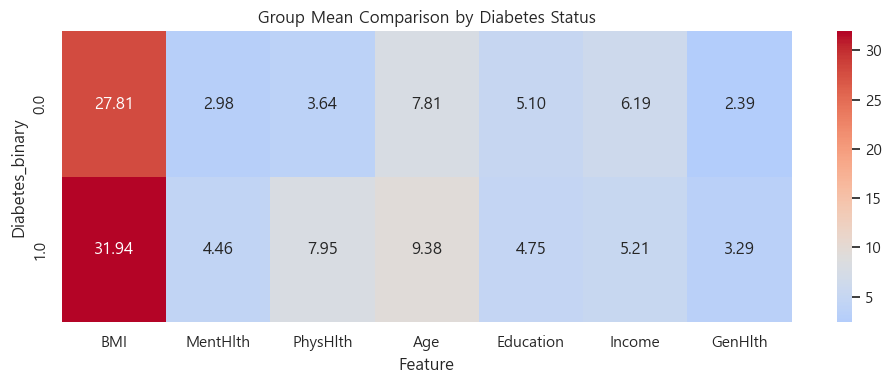

In [2]:
group_stats = df.groupby('Diabetes_binary')[continuous_features].agg(['mean', 'std']).round(3)
group_means = df.groupby('Diabetes_binary')[continuous_features].mean()
mean_diff = (group_means.loc[1.0] - group_means.loc[0.0]).sort_values(ascending=False)

print('연속형 피처 그룹별 평균 및 표준편차:')
display(group_stats)
print('평균 차이 (당뇨군 - 정상군):')
display(mean_diff.to_frame(name='평균 차이'))

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(group_means, annot=True, fmt='.2f', cmap='coolwarm', center=group_means.values.mean(), ax=ax)
ax.set_title('당뇨 여부별 그룹 평균 비교')
ax.set_xlabel('피처')
ax.set_ylabel('당뇨 여부')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_group_stats_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 섹션 3 — 카이제곱 검정 (이진 피처)

Chi-square test results sorted by Chi2 statistic:


,Feature,Chi2,p-value,Degrees of Freedom,Significant
0,HighBP,17562.446090,0.000000e+00,1,True
12,DiffWalk,12092.319741,0.000000e+00,1,True
1,HighChol,10174.074889,0.000000e+00,1,True
5,HeartDiseaseorAttack,7971.155841,0.000000e+00,1,True
6,PhysActivity,3539.419370,0.000000e+00,1,True
4,Stroke,2838.916547,0.000000e+00,1,True
2,CholCheck,1062.938144,3.751399e-233,1,True
3,Smoker,937.055759,8.640172e-206,1,True
9,HvyAlcoholConsump,825.118756,1.865932e-181,1,True
8,Veggies,811.805975,1.463029e-178,1,True


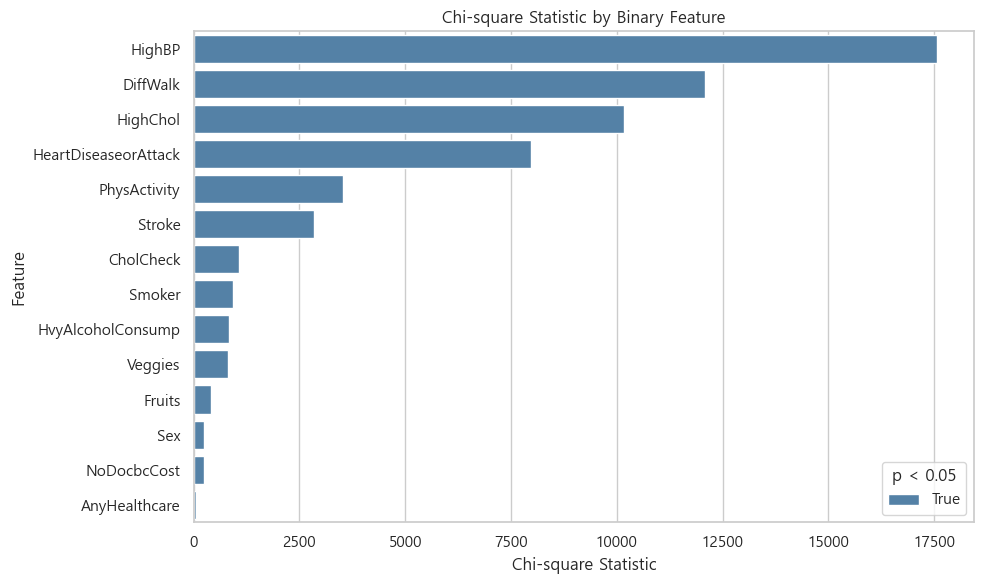

In [3]:
chi2_results = []
for col in binary_features:
    ct = pd.crosstab(df[col], df['Diabetes_binary'])
    chi2, p_value, dof, expected = chi2_contingency(ct)
    chi2_results.append({'Feature': col, 'Chi2': chi2, 'p-value': p_value, 'Degrees of Freedom': dof, 'Significant': p_value < 0.05})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
print('카이제곱 검정 결과 (Chi2 통계량 기준 정렬):')
display(chi2_df)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=chi2_df, x='Chi2', y='Feature', hue='Significant', dodge=False, palette={True: 'steelblue', False: 'lightgray'}, ax=ax)
ax.set_title('이진 피처별 카이제곱 통계량')
ax.set_xlabel('카이제곱 통계량')
ax.set_ylabel('피처')
legend = ax.get_legend()
if legend is not None:
    legend.set_title('유의성 (p < 0.05)')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_chi2_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 섹션 4 — 독립표본 t-검정 (연속형 피처)

Independent t-test results sorted by absolute t-statistic:


,Feature,t-stat,abs t-stat,p-value,Mean Diabetic,Mean Normal,Mean Difference
6,GenHlth,156.144220,156.144220,0.000000e+00,3.290981,2.385185,0.905796
3,Age,111.308487,111.308487,0.000000e+00,9.379053,7.814065,1.564988
0,BMI,99.919629,99.919629,0.000000e+00,31.944011,27.805770,4.138241
5,Income,-78.077488,78.077488,0.000000e+00,5.210094,6.190474,-0.980380
2,PhysHlth,68.968826,68.968826,0.000000e+00,7.954479,3.641082,4.313397
4,Education,-58.979063,58.979063,0.000000e+00,4.745516,5.099797,-0.354281
1,MentHlth,29.694812,29.694812,7.929124e-192,4.461806,2.978034,1.483772


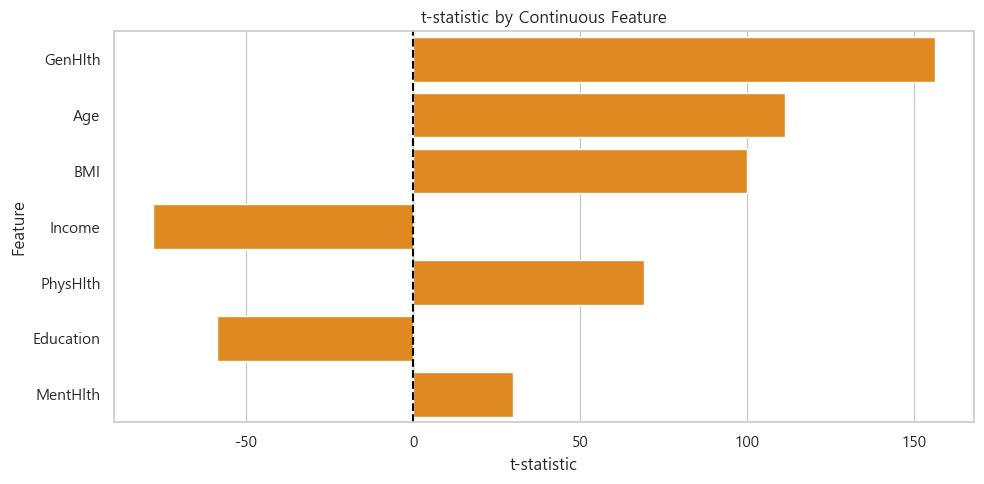

In [4]:
ttest_results = []
diabetic = df[df['Diabetes_binary'] == 1]
normal = df[df['Diabetes_binary'] == 0]

for col in continuous_features:
    t_stat, p_value = ttest_ind(diabetic[col], normal[col], equal_var=False)
    ttest_results.append({'Feature': col, 't-stat': t_stat, 'abs t-stat': abs(t_stat), 'p-value': p_value, 'Mean Diabetic': diabetic[col].mean(), 'Mean Normal': normal[col].mean(), 'Mean Difference': diabetic[col].mean() - normal[col].mean()})

ttest_df = pd.DataFrame(ttest_results).sort_values('abs t-stat', ascending=False)
print('독립표본 t-검정 결과 (t-통계량 절대값 기준 정렬):')
display(ttest_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=ttest_df, x='t-stat', y='Feature', color='darkorange', ax=ax)
ax.axvline(0, color='black', linestyle='--')
ax.set_title('연속형 피처별 t-통계량')
ax.set_xlabel('t-통계량')
ax.set_ylabel('피처')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_ttest_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 섹션 5 — 로지스틱 회귀 오즈비

Logistic regression odds ratios sorted in descending order:


,Feature,Coefficient,Odds Ratio,Distance from 1.0
13,GenHlth,0.681562,1.976964,0.976964
3,BMI,0.555471,1.742762,0.742762
18,Age,0.519924,1.681899,0.681899
0,HighBP,0.363862,1.438876,0.438876
1,HighChol,0.297277,1.346188,0.346188
2,CholCheck,0.254824,1.290234,0.290234
17,Sex,0.138142,1.148139,0.148139
6,HeartDiseaseorAttack,0.061106,1.063012,0.063012
5,Stroke,0.034261,1.034855,0.034855
16,DiffWalk,0.024767,1.025077,0.025077


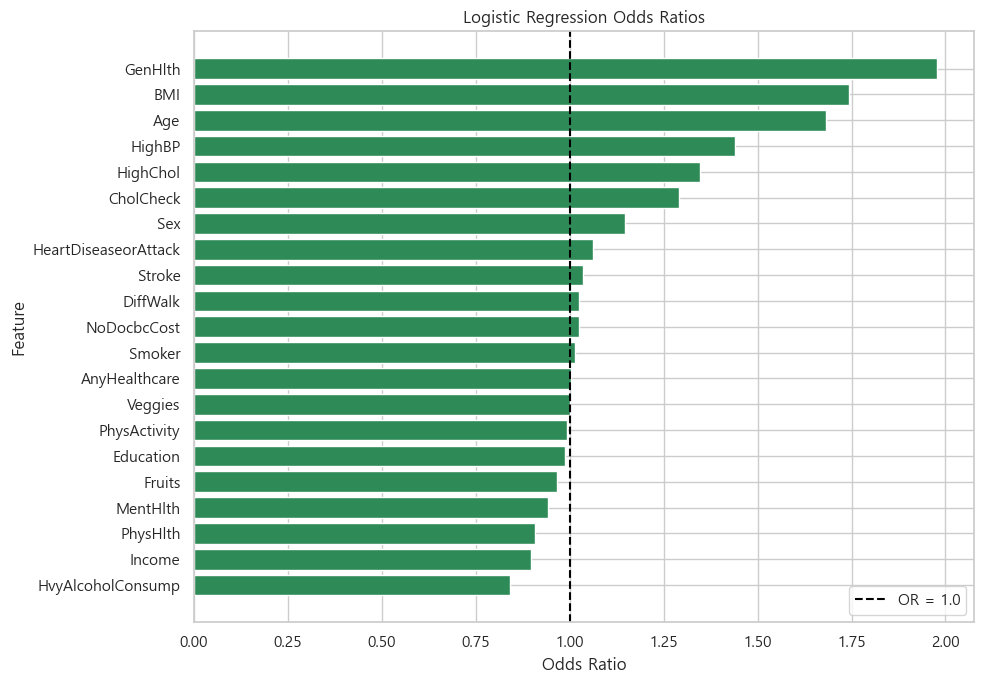

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_df, y_train)

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0]),
})
coef_df['Distance from 1.0'] = (coef_df['Odds Ratio'] - 1.0).abs()
coef_df = coef_df.sort_values('Odds Ratio', ascending=False)

print('로지스틱 회귀 오즈비 (내림차순 정렬):')
display(coef_df)

plot_df = coef_df.sort_values('Odds Ratio', ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df['Feature'], plot_df['Odds Ratio'], color='seagreen')
ax.axvline(1.0, color='black', linestyle='--', label='기준선 (OR = 1.0)')
ax.set_title('로지스틱 회귀 오즈비')
ax.set_xlabel('오즈비')
ax.set_ylabel('피처')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_odds_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## 섹션 6 — 주요 통계 발견

**유의한 이진 피처 (카이제곱, p < 0.05):** 14개 이진 피처 전체가 유의함.

**t-검정 기준 상위 피처:**
1. **GenHlth**: 당뇨군 평균 3.291 vs 정상군 2.385, t = 156.1
2. **Age**: 당뇨군 평균 9.379 vs 정상군 7.814, t = 111.3
3. **BMI**: 당뇨군 평균 31.944 vs 정상군 27.806, t = 99.9
4. **Income**: 당뇨군 평균 5.210 vs 정상군 6.190, t = -78.1 (저소득일수록 위험 증가)
5. **PhysHlth**: 당뇨군 평균 7.954 vs 정상군 3.641, t = 69.0

**오즈비 기준 상위 피처:**
1. **GenHlth**: OR = 1.977 — 건강 상태 1단계 나쁠수록 당뇨 위험 약 2배
2. **BMI**: OR = 1.743 — 표준화 단위 증가 시 당뇨 위험 약 1.7배
3. **Age**: OR = 1.682 — 연령 증가에 따른 위험 상승
4. **HighBP**: OR = 1.439 — 고혈압 있을 시 위험 약 1.4배
5. **HighChol**: OR = 1.346 — 고콜레스테롤 있을 시 위험 약 1.3배

이 결과는 섹션 4 의사결정 노트북의 위험군 프로파일 및 정책 시나리오 근거로 활용된다.